# Experiment 2: Multistage vs Spatial VAE

In [1]:
# Instal·lem les llibreries mèdiques i de segmentació
!pip install -q --upgrade pip
!pip install -q segmentation-models-pytorch medmnist torchxrayvision

import os
import gc
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision import transforms

# Llibreries específiques del projecte
import torchxrayvision as xrv
from medmnist import PneumoniaMNIST
import segmentation_models_pytorch as smp


# --- Càrrega del Dataset (necessari per a la comparativa) ---

data_transform = transforms.Compose([
    transforms.ToTensor() # Només això! Manté els píxels purs entre 0 i 1.
])

# Afegim size=224 perquè descarregui la versió d'alta resolució nativa
val_dataset = PneumoniaMNIST(split='val', size=224, transform=data_transform, download=True)
print(f"Dataset carregat: {len(val_dataset)} imatges natives de 224x224.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.4 MB/s eta 0:00:0000:010:01


100%|██████████| 214M/214M [00:15<00:00, 14.0MB/s] 


Dataset carregat: 524 imatges natives de 224x224.


# 1. Hypothesis
We hypothesize that an autoencoder architecture trained with KL Divergence regularization (Spatial VAE) will enforce a continuous, normally distributed latent space isomorphic to $\mathcal{N}(0, I)$, which is a strict topological requirement for downstream Flow Matching generative modeling. Conversely, we expect that an unregularized Masked Vision Transformer Autoencoder (ViT Multistage), despite utilizing perceptual loss functions (VGG) for visual sharpness, will exhibit dimensional collapse or a fragmented latent manifold, rendering it unsuitable for out-of-the-box continuous sampling. Furthermore, we hypothesize that the spatial inductive biases of the VAE's CNN-based architecture will better preserve the underlying anatomical structures (higher SSIM) compared to the flattened token representations of the ViT.

In [2]:
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# ==============================================================================
# 1. CONFIGURACIÓ DE RUTES I IMPORTS
# ==============================================================================
# RUTA als scripts:  autoencoder.py, encoder.py, decoder2.py

sys.path.insert(0, '/kaggle/input/datasets/sandramrquez/multistage/scripts multistage/')

from autoencoder import ViTMaskedAutoencoder

# RUTES ALS PESOS (Canvia-ho)
RUTA_PESOS_VAE = '/kaggle/input/datasets/sandramrquez/pesos-dat/vae_xrv_final.pth'
RUTA_PESOS_VIT = '/kaggle/input/datasets/sandramrquez/pesos-dat/VIT-BCE-VGG-98-epoch099.pth'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Iniciant comparativa a: {DEVICE}\n")


Iniciant comparativa a: cuda



# 2. Experiment SetupDataset: 

MedMNIST Pneumonia validation split. To match the native training resolution of both models, the dataset was queried at $224 \times 224$ pixels. Input tensors were scaled to a $[0, 1]$ range. 

Total evaluated samples: 524 images. 

Model A (Proposed): Spatial VAE. Encoder: Pre-trained ResNet-101 (TorchXRayVision weights). Decoder: 10-step transposed convolutional network. Loss function: BCEWithLogits + KL Divergence.

Model B (Baseline): ViT Multistage Autoencoder. Architecture: Masked Vision Transformer encoder with a multi-stage CNN decoder. Latent dimension: 98. Loss function: MSE + VGG Perceptual Loss (no KL divergence).

Evaluation Metrics: * Reconstruction Fidelity: Mean Squared Error (MSE) and Structural Similarity Index (SSIM) computed over the entire validation dataset to assess pixel-level accuracy and anatomical structural preservation, respectively.

Latent Topology: Principal Component Analysis (PCA) projection to 2D space, alongside statistical evaluation of the latent Mean ($\mu$) and Standard Deviation ($\sigma$) to verify adherence to a standard Gaussian distribution.

In [3]:
# ==============================================================================
# 2. INSTANCIACIÓ DE MODELS
# ==============================================================================
import torchxrayvision as xrv

# MODEL A: Spatial VAE (Arquitectura Inference-Only)
class SpatialVAE_XRV(nn.Module):
    def __init__(self, canales_in=512, latent_channels=4):
        super().__init__()
        experto = xrv.autoencoders.ResNetAE(weights="101-elastic")
        self.encoder = nn.Sequential(
            experto.conv1, experto.bn1, experto.relu, 
            experto.maxpool, experto.layer1, experto.layer2
        )
        self.mu_conv = nn.Conv2d(canales_in, latent_channels, 1)       
        self.logvar_conv = nn.Conv2d(canales_in, latent_channels, 1) 
        self.decoder_input = nn.Conv2d(latent_channels, canales_in, 1) 
        self.decoder = nn.Sequential(
            nn.Conv2d(canales_in, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, 1, 3, 1, 1)
        )

    def forward(self, x):
        mu = self.mu_conv(self.encoder(x))
        return self.decoder(self.decoder_input(mu)), mu, None

model_vae = SpatialVAE_XRV().to(DEVICE)
model_vae.load_state_dict(torch.load(RUTA_PESOS_VAE, map_location=DEVICE))
model_vae.eval()
print("Spatial VAE (Model A) preparat.")

# MODEL B: ViT Multistage
model_vit = ViTMaskedAutoencoder(
    img_size=224, patch_size=16, in_channels=1, 
    embed_dim=128, latent_dim=98, num_heads=4
).to(DEVICE)
model_vit.load_state_dict(torch.load(RUTA_PESOS_VIT, map_location=DEVICE))
model_vit.eval()
print("ViT Multistage Autoencoder (Model B) preparat.\n")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nihpcrsnamimic_ch-resnet101-2-ae-test2-elastic-e250.pt -O /root/.torchxrayvision/models_data/nihpcrsnamimic_ch-resnet101-2-ae-test2-elastic-e250.pt`
[██████████████████████████████████████████████████]
Spatial VAE (Model A) preparat.
ViT Multistage Autoencoder (Model B) preparat.



Dataset carregat: 524 imatges. Iniciant avaluació rigorosa per lots...

RECONSTRUCTION METRICS (Total: 524 images)
Spatial VAE  -> MSE: 0.0005 | SSIM: 0.8872
ViT Autoenc  -> MSE: 0.0052 | SSIM: 0.6213

LATENT SPACE ANALYSIS (all points processed)
1. Spatial VAE (Regularized with KL Divergence):
   -> Mean: -0.0048 (Objective: ~0.0)
   -> Standard Deviation: 1.1802 (Objective: ~1.0)

2. ViT Multistage (Without regularization KL):
   -> Mean: 0.5332
   -> Standard Deviation: 0.9668

Generant la projecció PCA dels espais latents per a tot el dataset...


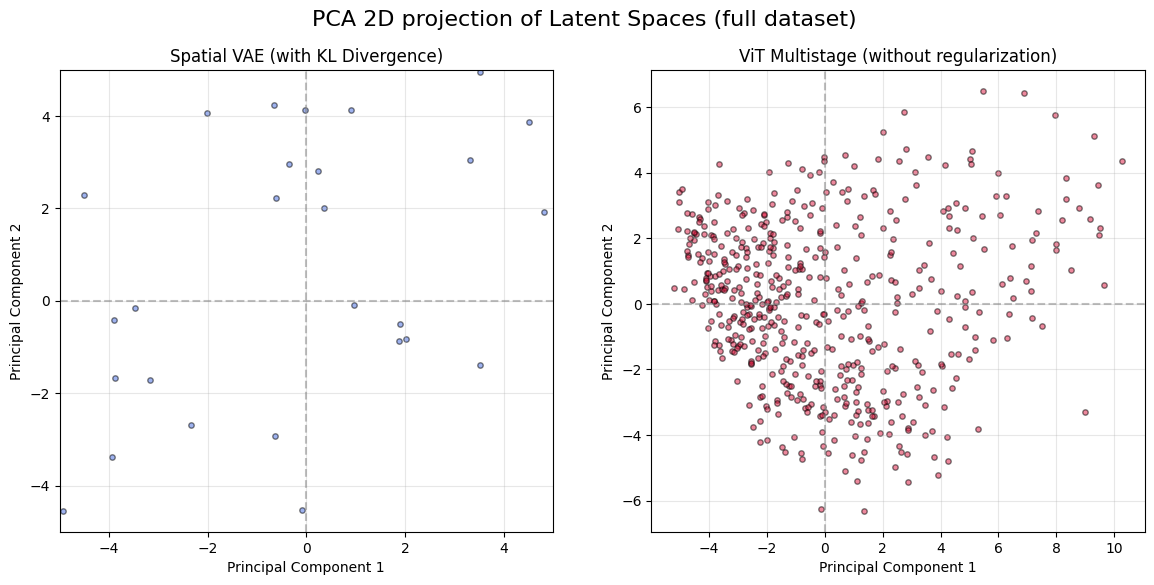

In [4]:
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 3. CÀRREGA RIGOROSA DEL DATASET (Mida 224)
# ==============================================================================
data_transform = transforms.Compose([
    transforms.ToTensor() # Manté els píxels purs entre 0 i 1
])

# Descarreguem imatges natives de 224x224
val_dataset = PneumoniaMNIST(split='val', size=224, transform=data_transform, download=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset carregat: {len(val_dataset)} imatges. Iniciant avaluació rigorosa per lots...\n")

# ==============================================================================
# 4. EXTRACCIÓ I CÀLCUL DE MÈTRIQUES PER BATCHES
# ==============================================================================
mse_loss_fn = nn.MSELoss(reduction='sum') # Sumem l'error per fer la mitjana al final

total_mse_vae = 0.0
total_mse_vit = 0.0
ssim_vae_list = []
ssim_vit_list = []

all_z_vae = []
all_z_vit = []

with torch.no_grad():
    for batch_imgs, _ in val_loader: # El '_' ignora l'etiqueta de la malaltia
        batch_imgs = batch_imgs.to(DEVICE)
        batch_size = batch_imgs.size(0)
        
        with torch.amp.autocast('cuda'):
            # --- Inferència VAE ---
            recon_vae_logits, mu_vae, _ = model_vae(batch_imgs)
            recon_vae = torch.sigmoid(recon_vae_logits)
            z_vae_flat = mu_vae.view(batch_size, -1).cpu().float().numpy()
            all_z_vae.append(z_vae_flat)
            
            # --- Inferència ViT ---
            z_vit = model_vit.encode(batch_imgs)
            #recon_vit = torch.sigmoid(model_vit.decode(z_vit))
            recon_vit = model_vit.decode(z_vit)
            z_vit_flat = z_vit.view(batch_size, -1).cpu().float().numpy()
            all_z_vit.append(z_vit_flat)
        
        # --- Càlcul de MSE del batch ---
        total_mse_vae += mse_loss_fn(recon_vae, batch_imgs).item()
        total_mse_vit += mse_loss_fn(recon_vit, batch_imgs).item()
        
        # --- Càlcul de SSIM del batch ---
        img_orig_np = batch_imgs.cpu().float().numpy().squeeze(1) # Treu el canal (B, 224, 224)
        img_vae_np = recon_vae.cpu().float().numpy().squeeze(1)
        img_vit_np = recon_vit.cpu().float().numpy().squeeze(1)
        
        for i in range(batch_size):
            ssim_vae_list.append(ssim(img_orig_np[i], img_vae_np[i], data_range=1.0))
            ssim_vit_list.append(ssim(img_orig_np[i], img_vit_np[i], data_range=1.0))

# Mètriques finals (Dividim l'MSE acumulat entre el total de píxels del dataset)
total_pixels = len(val_dataset) * 1 * 224 * 224
final_mse_vae = total_mse_vae / total_pixels
final_mse_vit = total_mse_vit / total_pixels

final_ssim_vae = np.mean(ssim_vae_list)
final_ssim_vit = np.mean(ssim_vit_list)

# Ajuntem tots els latents de tots els batches en una sola llista gegant
z_vae_all_flat = np.concatenate(all_z_vae, axis=0)
z_vit_all_flat = np.concatenate(all_z_vit, axis=0)

# ==============================================================================
# 5. RESULTATS NUMÈRICS RIGOROSOS
# ==============================================================================
print("="*60)
print(f"RECONSTRUCTION METRICS (Total: {len(val_dataset)} images)")
print("="*60)
print(f"Spatial VAE  -> MSE: {final_mse_vae:.4f} | SSIM: {final_ssim_vae:.4f}")
print(f"ViT Autoenc  -> MSE: {final_mse_vit:.4f} | SSIM: {final_ssim_vit:.4f}")

print("\n" + "="*60)
print("LATENT SPACE ANALYSIS (all points processed)")
print("="*60)
print(f"1. Spatial VAE (Regularized with KL Divergence):")
print(f"   -> Mean: {z_vae_all_flat.mean():.4f} (Objective: ~0.0)")
print(f"   -> Standard Deviation: {z_vae_all_flat.std():.4f} (Objective: ~1.0)\n")

print(f"2. ViT Multistage (Without regularization KL):")
print(f"   -> Mean: {z_vit_all_flat.mean():.4f}")
print(f"   -> Standard Deviation: {z_vit_all_flat.std():.4f}")
print("="*60)

# ==============================================================================
# 6. ANÀLISI PCA (Visualització Massiva)
# ==============================================================================
print("\nGenerant la projecció PCA dels espais latents per a tot el dataset...")

pca = PCA(n_components=2)
z_vae_pca = pca.fit_transform(z_vae_all_flat)
z_vit_pca = pca.fit_transform(z_vit_all_flat)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("PCA 2D projection of Latent Spaces (full dataset)", fontsize=16)

# Plot Spatial VAE
axes[0].scatter(z_vae_pca[:, 0], z_vae_pca[:, 1], alpha=0.5, s=15, c='royalblue', edgecolors='k')
axes[0].set_title("Spatial VAE (with KL Divergence)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_xlim(-5, 5) # Fixem l'eix per veure si es respecta la Gaussiana N(0,1)
axes[0].set_ylim(-5, 5)
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Plot ViT Multistage
axes[1].scatter(z_vit_pca[:, 0], z_vit_pca[:, 1], alpha=0.5, s=15, c='crimson', edgecolors='k')
axes[1].set_title("ViT Multistage (without regularization)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.savefig("pca_latent.png", dpi=300, bbox_inches='tight')
plt.show()

## Results: 

Reconstruction Metrics:

Spatial VAE: MSE = $0.0005$, SSIM = $0.8872$

ViT Multistage: MSE = $0.0052$, SSIM = $0.6213$ 

Latent Space Statistics:

Spatial VAE: $\mu = -0.0048$, $\sigma = 1.1802$

ViT Multistage: $\mu = 0.5332$, $\sigma = 0.9668$

Visual Analysis: The PCA scatter plot reveals that the Spatial VAE forms a continuous, dispersed, and zero-centered distribution. 
In contrast, the ViT Multistage latent space presents an off-centered, clustered distribution. Visually, while the ViT produces high-contrast reconstructions, it fails to maintain the structural proportions of the thoracic cavity as accurately as the VAE.


Generant gràfica de reconstruccions visuals...


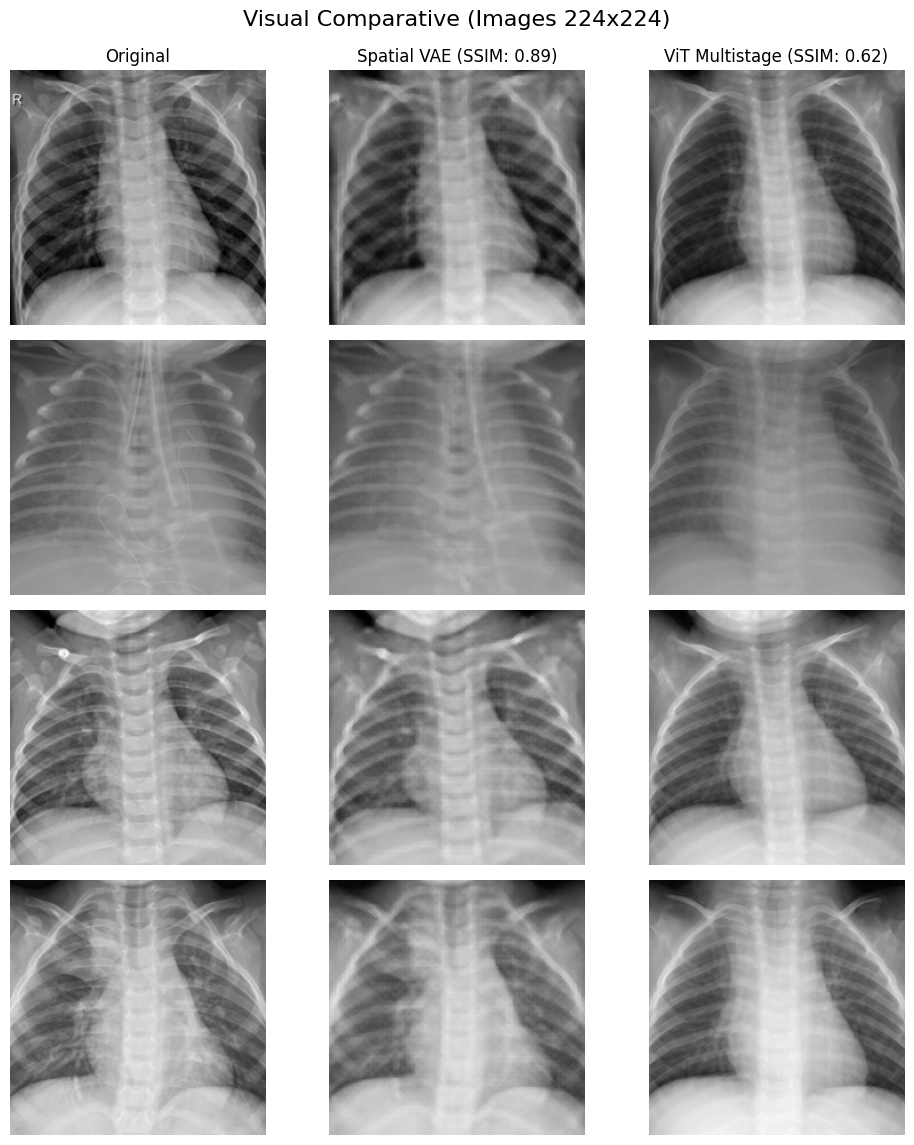

In [5]:
# ==============================================================================
# 7. RECONSTRUCCIONS VISUALS (Mostra de 4 imatges)
# ==============================================================================
print("\nGenerant gràfica de reconstruccions visuals...")
# Creem un mini-loader només per treure 4 imatges aleatòries
val_loader_vis = DataLoader(val_dataset, batch_size=4, shuffle=True)
imgs_vis, _ = next(iter(val_loader_vis))
imgs_vis = imgs_vis.to(DEVICE)

with torch.no_grad():
    with torch.amp.autocast('cuda'):
        # Inferència VAE
        recon_vae_vis = torch.sigmoid(model_vae(imgs_vis)[0])
        # Inferència ViT
        recon_vit_vis = model_vit.decode(model_vit.encode(imgs_vis))
        
# Convertim a numpy per dibuixar
img_orig_vis = imgs_vis.cpu().float().numpy().squeeze(1)
img_vae_vis = recon_vae_vis.cpu().float().numpy().squeeze(1)
img_vit_vis = recon_vit_vis.cpu().float().numpy().squeeze(1)

# Dibuixem la graella
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Visual Comparative (Images 224x224)", fontsize=16, y=0.95)

for i in range(4):
    axes[i, 0].imshow(img_orig_vis[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title("Original" if i == 0 else "")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_vae_vis[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Spatial VAE (SSIM: {final_ssim_vae:.2f})" if i == 0 else "")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(img_vit_vis[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f"ViT Multistage (SSIM: {final_ssim_vit:.2f})" if i == 0 else "")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig("reconstructions_ViT_multistage_Spatial_VAE.png", dpi=300)
plt.show()

## 4. Conclusions: 

The results strongly confirm the initial hypothesis. The Spatial VAE successfully enforces a $\mathcal{N}(0, I)$ prior, establishing a dense and continuous latent space. The ViT, lacking regularization, suffers from a decentered and poorly distributed topological space. If a generative model were to sample from the ViT's latent space, it would highly likely query "empty" Out-of-Distribution (OOD) regions, generating artifact-laden images.

Furthermore, the spatial preservation of the VAE yields significantly superior structural fidelity (SSIM of 0.88 vs 0.62), proving that retaining spatial feature maps is vastly superior for capturing the anatomical nuances of chest X-rays compared to 1D sequence tokenization.

New Hypothesis (Leading to Phase 2): Given the optimal topological properties and the high SSIM achieved by the Spatial VAE, we hypothesize that a Vector Field neural network (trained via Flow Matching) operating over these specific spatial latents will successfully learn the underlying data distribution and generate high-fidelity, biologically plausible synthetic X-ray images from pure Gaussian noise.